 # Práctica de aprendizaje automático (parte 3)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **sé intrépido y explora**. 

# Construcción de un clasificador en una base de datos real (3.5 puntos)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

%matplotlib inline

In [2]:
df = pd.read_csv('./data/german_credit_data.csv', sep=';')
# Source: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
# This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix

print(df.shape)
df.head(5)

(1000, 21)


,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [3]:
class_label = 'default'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['account_check_status ', 'duration_in_month ', 'credit_history ', 'purpose ', 'credit_amount ', 'savings ', 'present_emp_since ', 'installment_as_income_perc ', 'personal_status_sex ', 'other_debtors ', 'present_res_since ', 'property ', 'age ', 'other_installment_plans ', 'housing ', 'credits_this_bank ', 'job ', 'people_under_maintenance ', 'telephone ', 'foreign_worker']


**Estadísticos básicos de cada atributo:**

In [4]:
df.describe()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


**Datos codificados de forma numérica**

In [5]:
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


**Histogramas suavizados de cada atributo en cada clase. El color indica la clase ("default"/"no default"):**

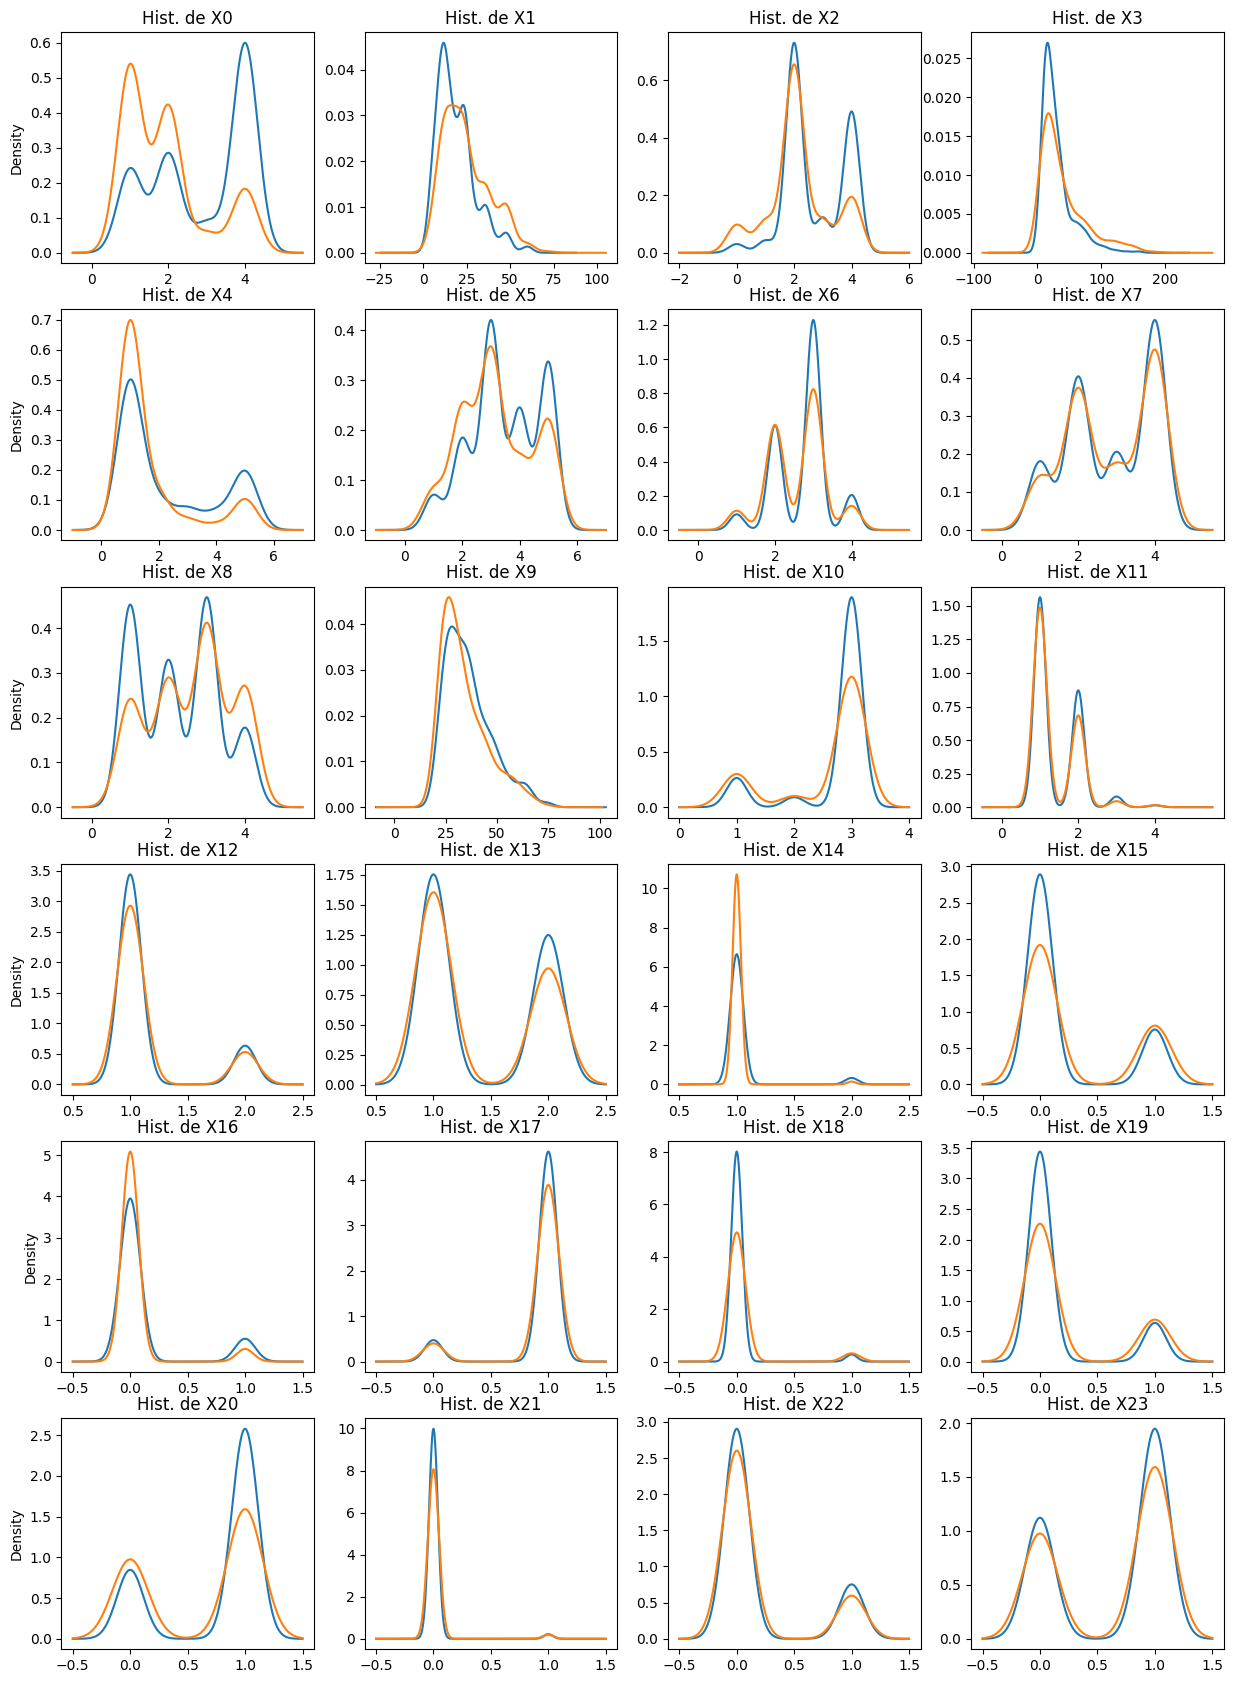

In [6]:
plt.figure(figsize=(15, 21))
n_cols_plot = 4
n_rows_plot = int(len(feature_names) / n_cols_plot)
for i,n in enumerate(feature_names):
    plt.subplot(n_rows_plot, n_cols_plot, i+1)
    aux = 'Density' if i%n_cols_plot == 0 else ''
    df.groupby('Class')[n].plot(kind='kde', title='Hist. de '+n)
    plt.ylabel(aux)
plt.show()

1. **Describe las características de los datos:**
    * **Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.**
      Hay 23 atributos, de los cuales:
      * 14 atributos nominales no ordenados: credit_history, personal_status, job, telephone, purpose, other_installment_plans, foreign_worker, housing y property.
      * 2 atributos nominal ordenado: account_check_status, present_emp_since.
      * 4 atributos numéricos no contínuos: installment_as_income_perc, people_under_maintenance, age y present_res_since.
      * 3 atributos numéricos contínuos.
    * **Tamaño del conjunto de datos.**
      1000 datos.
    * **¿Qué atributos parece que tendrán más relevancia para predicción?**
      Atendiendo a las gráficas, X0, X8 y X20 pueden ser más relevantes dado que sus muestras tienen comportamientos algo más diferenciados que el resto de atributos.

## 1. Entrenamiento de un modelo y chequeo de su calidad usando 5-fold cross validation

La siguiente celda entrena un modelo y lo evalúa en varias particiones training-test diferentes de los datos. El resultado es un score medio junto a su desviación estándar.

In [7]:
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# otros clasificadores (del notebook p4_01)

clf = KNeighborsClassifier(n_neighbors=1) # DecisionTreeClassifier(max_depth=3)
scores = cross_val_score(clf, X, y, cv=10) # 10-fold cross-validation
print('Precisión en cada una de las particiones: ', scores)
                                                                                #acierto          #desviacion
print('Estimación de la precisión por validación cruzada: {:.2f} +/- {:.2f}'.format(scores.mean(), scores.std()))

Precisión en cada una de las particiones:  [0.65 0.62 0.72 0.66 0.63 0.71 0.59 0.7  0.62 0.66]
Estimación de la precisión por validación cruzada: 0.66 +/- 0.04


### 1.1 Responde aquí a las siguientes preguntas:

   * **¿Cuál es el tamaño de los conjuntos de entrenamiento y test?**
     Sabiendo que la muestra es de 1000 datos y la distribución de la población en conjuntos es 90% entrenamiento y 10% test, el conjunto de entrenamiento es una muestra de 900 datos y el del test es de 100.
   * **¿Se ha usado estratificación en el muestreo o no se ha usado?**
     No.
   * **¿Cuál es el error del modelo y su variabilidad?**
     El error del modelo es 0.34 y la desviación es 0.04

### 1.2 Responde aquí a las siguientes preguntas:

* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).
* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.
* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?
* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.
* Resume los resultados y conclusiones del estudio realizado.

**Además de gráficas, puede ser conveniente presentar los resultados en forma de tablas.**

**Para comparar de forma efectiva los métodos, recuerda incluir las barras de error en las gráficas y el error estándar en las tablas.**

In [8]:
import math
from sklearn.neighbors import KNeighborsClassifier
trainingSample = math.floor(1000/10 * 10 - 1000/10) 
scores = []
errors = []
max_prec = (0,0)
knn = range(1,trainingSample, 50)
for n in knn:
    knnClf = KNeighborsClassifier(n_neighbors=n) 
    cvs = cross_val_score(knnClf, X, y, cv=10).mean()
    prec = cvs.mean()
    if not scores or max(scores) < prec:
        max_prec = (n, prec)
        std_max = cvs.std()
    scores.append(prec)
    errors.append(cvs.std())

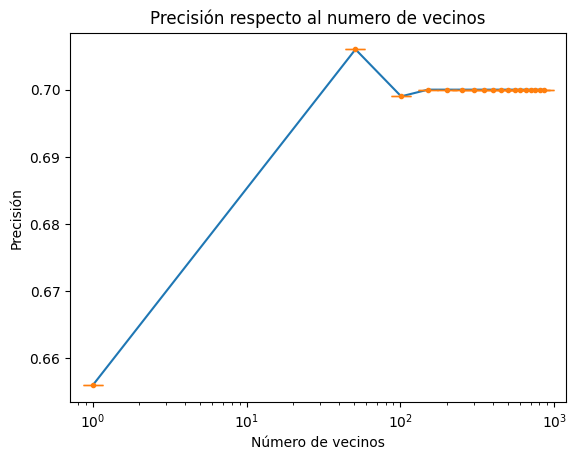

Vecinos para precisión máxima(0.706): 51
Desviacion para precisión máxima: 0.0


In [9]:
plt.semilogx(knn, scores)
plt.errorbar(knn, scores, errors, fmt='.', linewidth=1, capsize=7)
plt.xlabel('Número de vecinos')
plt.ylabel('Precisión')
plt.title('Precisión respecto al numero de vecinos')
plt.show()
print(f'Vecinos para precisión máxima({round(max_prec[1], 3)}): {max_prec[0]}\nDesviacion para precisión máxima: {std_max}')

Para un clasificador KNN el ajuste viene definido según el número de vecinos:
* Cuando el número de vecinos empieza a acercarse al tamaño de la muestra, se produce subajuste y se generaliza de más. Para el conjunto sobre el que estamos actuando, dicho fenómeno se produce para k > 51 y la precisión baja hasta quedarse estabilizada en 0,70.
* Cuando el número de vecinos es muy pequeño, tenemos un clasificador sobreajustado cuya precisión no va a ser la mayor posible. En nuestro caso, conforme vamos incrementado k hasta 51, la precisión aumenta hasta 0.706.

In [10]:
prof_max = math.floor(math.log2(trainingSample))
print(f'max depth for training set: {prof_max}')
profs = range(1, prof_max + 1)
scores = []
errors = []
max_prec = (0,0)
for p in profs:
    dTclf = DecisionTreeClassifier(criterion='entropy', max_depth=p)
    cvs = cross_val_score(dTclf, X, y, cv=10)
    prec = cvs.mean()
    if not scores or max(scores) < prec:
        max_prec_ABD = prec
        max_prec = (p, prec)
        std_max_p = cvs.std()
    scores.append(prec)
    errors.append(cvs.std())

max depth for training set: 9


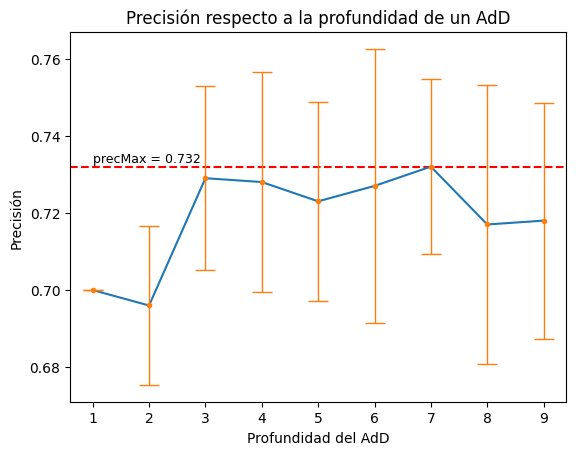

Profundidad para precisión máxima (0.732): 7
Desviación para precisión: 0.023
Desviación máxima registrada: 0.036


In [11]:
import numpy as np
plt.axhline(y=max_prec[1], color='r', linestyle='--')
plt.plot(profs, scores)
plt.text(1, max(scores) + 0.001, f'precMax = {round(max(scores), 3)}', fontsize=9)
plt.xticks(np.arange(min(profs), max(profs) + 1, 1.0))
plt.errorbar(profs, scores, errors, fmt='.', linewidth=1, capsize=7)
plt.xlabel('Profundidad del AdD')
plt.ylabel('Precisión')
plt.title('Precisión respecto a la profundidad de un AdD')
plt.show()
print(f'Profundidad para precisión máxima ({round(max_prec[1], 4)}): {max_prec[0]}\nDesviación para precisión: {round(std_max_p,3)}')
print(f'Desviación máxima registrada: {round(max(errors),3)}')

Cuando los árboles de decisión no son lo suficientemente profundos, pierden precisión por subajuste; y, como podemos apreciar en la gráfica, la precisión va incrementando según se amplíe la profundidad máxima que puede alcanzar. Si bien, a partir de cierta profundidad máxima (que en nuestro caso es 7) el clasificador vuelve a perder precisión, aunque en este caso es por sobreajuste, que es una de las principales desventajas -tienden a sobreadaptarse al conjunto de entrenamiento- de los árboles de decisión y que puede paliarse controlando la profundidad máxima u otras técnicas de pre-pruning. 
Cabe mencionar que el modelo, menos para la profundidad 1, tiene una desviación bastante alta, por lo cual, aun habiendo dicho que en las profundidades menores hay subajuste, una varianza tan grande puede ser un indicador de que el modelo ha sobreaprendido los conjuntos de entrenamiento.

In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
scores = []
errors = []
max_prec = (0,0)
nrns = range(10, trainingSample, 50)
for n in nrns:
    mlpclf = MLPClassifier(hidden_layer_sizes=(n,), max_iter=2700, alpha=0.0, random_state = 42, early_stopping = True)
    cvs = cross_val_score(mlpclf, X, y, cv=10)
    prec = cvs.mean()
    if not scores or max(scores) < prec:
        max_prec = (n, prec)
        std_max_p = cvs.std()
    scores.append(prec)
    errors.append(cvs.std())

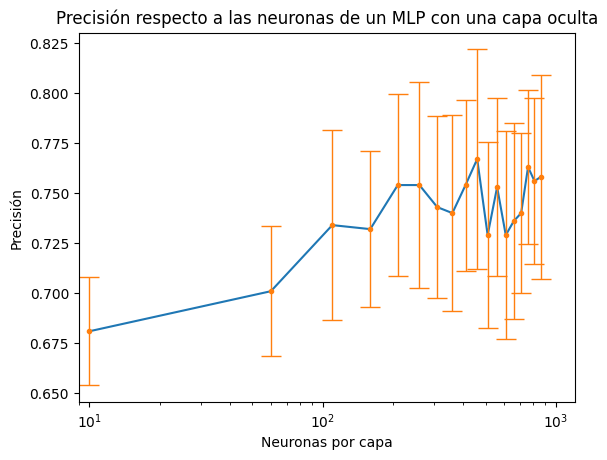

Neuronas para precisión máxima (0.767): 460
Desviación para precisión: 0.055
Desviación máxima registrada: 0.055


In [13]:
plt.semilogx(nrns, scores)
#plt.axhline(y=max_prec[1], color='r', linestyle='--')
#plt.axvline(x=max_prec[0], color='r', linestyle='--')
plt.errorbar(nrns, scores, errors, fmt='.', linewidth=1, capsize=7)
#plt.text(10, max(scores) + 0.0002, f'precMax = {round(max(scores), 3)}', fontsize=9)
plt.xlabel('Neuronas por capa')
plt.ylabel('Precisión')
plt.title('Precisión respecto a las neuronas de un MLP con una capa oculta')
plt.xlim(left=9) 
plt.show()
print(f'Neuronas para precisión máxima ({round(max_prec[1], 3)}): {max_prec[0]}\nDesviación para precisión: {round(std_max_p,3)}')
print(f'Desviación máxima registrada: {round(max(errors),3)}')

Por la curva que dibuja la gráfica, se puede ver un crecimiento semejante a una función lineal respecto al número de neuronas y la precisión del perceptrón. Creemos que los picos en la gráfica se pueden deber las direncias entre los folds y el sobreentrenamiento o subentrenamiento del modelo, que produce overfit o underfit respectivamente, pues max_iter no cambia. En lo que se refiere a estabilidad del modelo de 1 capa oculta, la varianza es relativamente alta, dado que para cada tasa de acierto medio, la horquilla de resultados puede llegar a ser de un +-5%.

Para poder evaluar la precisión con respecto a la configuración de las capas de un perceptrón, hemos decidido mantener fijo el número de neuronas y que estas se repartan de la forma más equitativa posible, haciendo la división entera entre el número de capas y el número de neuronas.

In [14]:
#¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? 
#Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, 
#suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.
#para cada capa vamos a tener 10 neuronas
scores = []
errors = []
max_prec = (0,0)
nlyrs = [1, 2, 5, 10, 25, 50]
for i in nlyrs:
    layers = (50//(i),)
    for l in range(1,i):
        layers = layers + (50//(i),)
    mlpclf = MLPClassifier(hidden_layer_sizes=layers, max_iter=650, alpha=0.0, random_state = 42)
    cvs = cross_val_score(mlpclf, X, y, cv=10)
    prec = cvs.mean()
    if not scores or max(scores) < prec:
        max_prec = (i, prec)
    scores.append(prec)
    errors.append(cvs.std())
    print(f'layer composition: {layers}')

layer composition: (50,)
layer composition: (25, 25)
layer composition: (10, 10, 10, 10, 10)
layer composition: (5, 5, 5, 5, 5, 5, 5, 5, 5, 5)
layer composition: (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)
layer composition: (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)


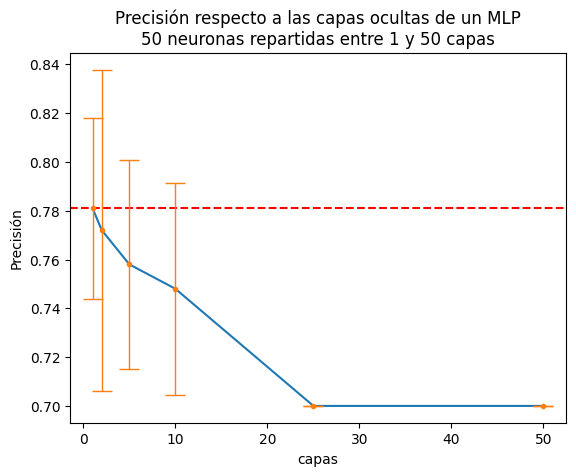

Capas para precisión máxima (0.781): 1


In [15]:
plt.axhline(y=max_prec[1], color='r', linestyle='--')
plt.plot(nlyrs, scores)
plt.errorbar(nlyrs, scores, errors, fmt='.', linewidth=1, capsize=7)
plt.xlabel('capas')
plt.ylabel('Precisión')
plt.title('Precisión respecto a las capas ocultas de un MLP\n50 neuronas repartidas entre 1 y 50 capas')
plt.show()
print(f'Capas para precisión máxima ({max_prec[1]}): {max_prec[0]}')

Podemos apreciar que para las distribuciones en las que hay más neuronas por capa, aunque la preción sea mayor, la desviación estándar es más alta que en aquellas en las que hay menos neuronas por capa, indicando que el rendimiento de dichos perceptrones es más inconsistente o sensible a los datos de cada estrato del k-fold (sobreajuste). Por ello, podemos decir que la configuración de capas afecta al rendimiento del mlp de tal manera que si un modelo tiene múltiples capas, en el caso de que la densidad de neuronas por capa no sea suficiente, el error inicial va a ser más alto y se va a necesitar más entrenamiento (iteraciones) para llegar la precisión máxima que pueda optar el perceptrón con dicha configuración de capas y neuronas.

## 2. Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados. Sin embargo, es importante evitar errores comunes como el goteo de información. Puedes obtener más información sobre buenas prácticas en: https://scikit-learn.org/stable/common_pitfalls.html

En este apartado debes investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados. Explora al menos los siguientes mecanismos:
   * Construcción y selección de atributos.
   * Preprocesamiento:
     * Detección de outliers.
     * Missing values.
     * Centrado (estandarización).
     * Escalado (normalización).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas). Además, explica la metodología utilizada para seguir unas buenas prácticas.

**Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.**

**Para comparar de forma efectiva los métodos, recuerda incluir las barras de error en las gráficas y el error estándar en las tablas.**

#### Construcción y selección de atributos
Para la construcción de atributos, según hemos podido ver en la página https://ds100.org/fa23-course-notes/feature_engineering/feature_engineering.html#feature-functions, existen las _feature functions_, que son funciones que permiten derivar atributos nuevos a partir de atributos ya existentes aplicando transformaciones. Con sklearn se pueden crear estos atributos con la función de preprocesado Pipeline(), que aplica las transformaciones que creamos convenientes, entre otras cosas. Normalmente esta técnica se utiliza cuando nos faltan atributos necesarios para mejorar el rendimiento de un modelo, o hay que sustituir otros atributos que no aportan o hacen ruido produciendo una bajada en la precisión del clasificador; aunque este último tipo de atributo puede ser eliminado mediante selección. En principio, dada la cantidad de atributos que ya tenemos, creemos que es prefible hacer otras prácticas de preprocesado y eliminación de atributos que no sean útiles antes de generar derivaciones. 

Para la selección de atributos hay otro paquete específico en sklearn, feature_selection, que nos permite seleccionar los K mejores atributos según distintas funciones de evaluación. De este paquete vamos a probar con los métodos SelectKBest, utilizando chi² como función para puntuar los atributos y RFE (Recursive Feature Elimination) para ver cómo afectan al entrenamiento de un perceptrón con dos capas ocultas de 50 neuronas cada una y a un árbol de decisión.

In [ ]:
# Construcción y selección de atributos.
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split

scores_chi = []
scores_rfe = []
errors_chi = []
errors_rfe = []
#como vamos a utilizar cross_validation_score, no hace falta hacer un split de los datos por nuestra parte
mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)

n_features = range(1, len(feature_names)+1)
for n in n_features:
    select_k_best = SelectKBest(score_func=chi2, k=n)
    X_k_best_chi2 = select_k_best.fit_transform(X, y)
    
    rfe = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=n)
    rfe.fit(X, y)
    X_rfe_sel = rfe.transform(X)
    
    cvs_chi = cross_val_score(mlpclf, X_k_best_chi2, y, cv=10)
    cvs_rfe = cross_val_score(mlpclf, X_rfe_sel, y, cv=10)
    prec_chi = cvs_chi.mean()
    prec_rfe = cvs_rfe.mean()
    if not scores_chi or max(scores_chi) < prec_chi:
        max_prec_chi = (n, prec_chi)
        std_max_chi = cvs_chi.std()
    if not scores_rfe or max(scores_rfe) < prec_rfe:
        max_prec_rfe = (n, prec_rfe)
        std_max_rfe = cvs_rfe.std()

    scores_chi.append(prec_chi)
    errors_chi.append(cvs_chi.std())
    scores_rfe.append(prec_rfe)
    errors_rfe.append(cvs_rfe.std())

Selección de atributos para un MLP:


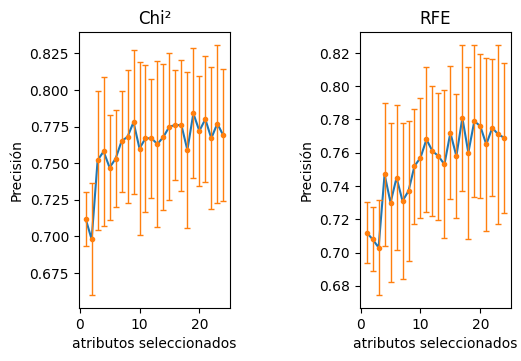

Atributos para precisión máxima con chi²(0.784): 19
Atributos para precisión máxima con rfe(0.781): 17
Desviación para precisión máxima con chi²: 0.044
Desviación para precisión máxima con rfe: 0.044
Desviación máxima registrada con chi²: 0.059
Desviación máxima registrada con rfe: 0.054
Precisión máxima sin selección de atributos 0.769


In [17]:
print('Selección de atributos para un MLP:')
fig, ax = plt.subplots(1, 2)
ax[0].set_xlabel('atributos seleccionados')
ax[0].set_ylabel('Precisión')
ax[0].plot(n_features, scores_chi)
ax[0].errorbar(n_features, scores_chi, errors_chi, fmt='.', linewidth=1, capsize=2)
ax[0].set_title('Chi²')
ax[1].set_xlabel('atributos seleccionados')
ax[1].set_ylabel('Precisión')
ax[1].plot(n_features, scores_rfe)
ax[1].errorbar(n_features, scores_rfe, errors_rfe, fmt='.', linewidth=1, capsize=2)
ax[1].set_title('RFE')
fig.tight_layout(pad=5.0)
plt.show()
print(f'Atributos para precisión máxima con chi²({round(max_prec_chi[1], 4)}): {max_prec_chi[0]}\nAtributos para precisión máxima con rfe({round(max_prec_rfe[1], 4)}): {max_prec_rfe[0]}')
print(f'Desviación para precisión máxima con chi²: {round(std_max_chi,3)}\nDesviación para precisión máxima con rfe: {round(std_max_rfe,3)}')
print(f'Desviación máxima registrada con chi²: {round(max(errors_chi),3)}\nDesviación máxima registrada con rfe: {round(max(errors_rfe),3)}')
print(f'Precisión máxima sin selección de atributos {round(scores_chi[-1], 4)}')

Los máximos de precisión del mlp se obtienen con 19 atributos en lugar de 24 para ambos métodos de selección; si bien, parece que el riterio de selección de chi² es ligeramente mejor para este set de datos para el MLP. Aunque la varianza en ambos casos hace que en el peor de los casos, la precisión no llega al 80% de aciertos de clasificación y la diferencia entre hacer selección de atributos o no, es de apenas 2 puntos (78.4% y 77.9% vs 76.9%); por ello, seguramente habría que aplicar conjuntamente otras técnicas de preprocesado o buscar otros criterios de selección para este perceptrón en particular.

In [18]:
scores_chi = []
scores_rfe = []
errors_chi = []
errors_rfe = []

dTclf = DecisionTreeClassifier(criterion='entropy', max_depth=7)

n_features = range(1, len(feature_names)+1)
for n in n_features:
    select_k_best = SelectKBest(score_func=chi2, k=n)
    X_k_best_chi2 = select_k_best.fit_transform(X, y)
    
    rfe = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=n)
    rfe.fit(X, y)
    X_rfe_sel = rfe.transform(X)
    
    cvs_chi = cross_val_score(dTclf, X_k_best_chi2, y, cv=10)
    cvs_rfe = cross_val_score(dTclf, X_rfe_sel, y, cv=10)
    prec_chi = cvs_chi.mean()
    prec_rfe = cvs_rfe.mean()
    if not scores_chi or max(scores_chi) < prec_chi:
        max_prec_chi = (n, prec_chi)
        std_max_chi = cvs_chi.std()
    if not scores_rfe or max(scores_rfe) < prec_rfe:
        max_prec_rfe = (n, prec_rfe)
        std_max_rfe = cvs_rfe.std()

    scores_chi.append(prec_chi)
    errors_chi.append(cvs_chi.std())
    scores_rfe.append(prec_rfe)
    errors_rfe.append(cvs_rfe.std())

Selección de atributos para AbdD:


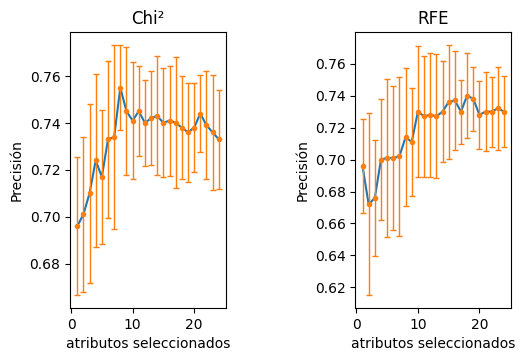

Atributos para precisión máxima con chi²(0.755): 8
Atributos para precisión máxima con rfe(0.74): 18
Desviación para precisión máxima con chi²: 0.018
Desviación para precisión máxima con rfe: 0.026
Desviación máxima registrada con chi²: 0.039
Desviación máxima registrada con rfe: 0.057
Precisión máxima sin selección de atributos 0.732


In [19]:
print('Selección de atributos para AbdD:')
fig, ax = plt.subplots(1, 2)
ax[0].set_xlabel('atributos seleccionados')
ax[0].set_ylabel('Precisión')
ax[0].plot(n_features, scores_chi)
ax[0].errorbar(n_features, scores_chi, errors_chi, fmt='.', linewidth=1, capsize=2)
ax[0].set_title('Chi²')
ax[1].set_xlabel('atributos seleccionados')
ax[1].set_ylabel('Precisión')
ax[1].plot(n_features, scores_rfe)
ax[1].errorbar(n_features, scores_rfe, errors_rfe, fmt='.', linewidth=1, capsize=2)
ax[1].set_title('RFE')
fig.tight_layout(pad=5.0)
plt.show()
print(f'Atributos para precisión máxima con chi²({round(max_prec_chi[1], 4)}): {max_prec_chi[0]}\nAtributos para precisión máxima con rfe({round(max_prec_rfe[1], 4)}): {max_prec_rfe[0]}')
print(f'Desviación para precisión máxima con chi²: {round(std_max_chi,3)}\nDesviación para precisión máxima con rfe: {round(std_max_rfe,3)}')
print(f'Desviación máxima registrada con chi²: {round(max(errors_chi),3)}\nDesviación máxima registrada con rfe: {round(max(errors_rfe),3)}')
print(f'Precisión máxima sin selección de atributos {round(max_prec_ABD, 4)}')


Por otro lado, la mejora de precisión del árbol con selección de atributos en el conjunto de datos es algo mejor; con la eliminación recursiva la precisión mejora en 0.048 y la desviación es relativamente aceptable para la precisión máxima, aunque necesita más del doble de atributos que SelectKBest+chi² para obtener una precisión del 73.7% en lugar del 75.4%, por lo que parece que para este conjunto de datos, SelectKBest obtiene mejores resultados a la hora de seleccionar atributos en caso de querer reducir considerablemente el tamaño de nuestro input.

#### Detección de outliers
Para detectar y eliminar outliers tenemos varias opciones, entre las cuales están:
* Eliminación por umbral: se establece un límite arbitrario a partir del cual se eliminan entradas del conjunto de datos.
* Z-score/standard score: en donde se aplica la fórmula Z = (x - μ)/σ tal que x es el dato en una cierta columna de x al que se le sustrae la media y después se divide por la varianza. Se suele dar un valor umbral para Z a partir del cual, el dato se considera outlier.
* Rango intercuantil: detección outliers a partir de cuantiles, con este método se consideran como outliers aquellos datos que estén por debajo de Q1 o están por encima de Q3. El rango define IQR = Q3 - Q1 y los umbrales son upper = Q3 + 1.5 ∗ IQR y lower = Q1 − 1.5∗IQR.
Normalmente la detección de outliers se suele aplicar en los atributos que más útiles son para la clasificación, es decir, se tienen que seleccionar en qué atributos se va a hacer este preprocesado.

Con los dos modelos anteriores, vamos a probar a hacer detección de outliers con Z-score y el rango intercuantil sobre los tres mejores atributos según SelectKBest+chi2:

Nota: hay otros métodos en sklearn como lo RobustCovariance, IsolationForest, LocalOutlierFactor o One Class SVM (SDG), que for falta de recursos hardware no podemos probar en condiciones (los ordenadores que tenemos casa se quedan con la RAM colapsada)

In [21]:
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
import numpy as np

threshold = 2 #clasificamos como outlier aquellas z-scores superiores a 2

X_out = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
y_out = X_out['Class'].values
del X_out['Class']
feature_names = list(X_out.columns)


mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)
select_k_best = SelectKBest(score_func=chi2, k=3)
X_k_best_chi2 = select_k_best.fit_transform(X_out, y_out)

features = list(X_out.columns[select_k_best.get_support()])

df_k3 = pd.DataFrame(X_k_best_chi2, columns=features)
print('Detección de outliers con Z-score')
idxs = []
for f in features:
    #z scores para el atributo
    z_scores = np.abs(zscore(df_k3[f]))
    #outliers
    [idxs.append(i) for i in np.where(z_scores > threshold)[0] if i not in idxs]
print(f'Outliers: {len(idxs)}')
#reajustamos los resultados de la clases de y
df_k3['Class'] = y_out
df_k3_clean = df_k3.drop(idxs)
y_clean = df_k3_clean['Class'].values

print('Datos originales (k=3):', df_k3.shape, ' Datos sin outliers:', df_k3_clean.shape)
#Vamos a comparar 
cvs_raw = cross_val_score(mlpclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(mlpclf, df_k3_clean[features].values, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')

print('\nDetección de outliers con IQR')
#rangos de cada atributo
idx = []
for f in features:
    q1 = df_k3[f].quantile(0.25)
    q3 = df_k3[f].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr 
    up_idx = np.where(df_k3[f] >= upper)[0]
    low_idx = np.where(df_k3[f] <= lower)[0]
    [idxs.append(i) for i in up_idx if i not in idxs]
    [idxs.append(i) for i in low_idx if i not in idxs]
print('Outliers: ', len(idxs))

df_k3_clean = df_k3.drop(idxs)
y_clean = df_k3_clean['Class'].values

print('Datos originales (k=3):', df_k3.shape, ' Datos sin outliers:', df_k3_clean.shape)
#Vamos a comparar 
cvs_raw = cross_val_score(mlpclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(mlpclf, df_k3_clean[features].values, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')


Detección de outliers con Z-score
Outliers: 97
Datos originales (k=3): (1000, 4)  Datos sin outliers: (903, 4)
Precisión media sin eliminación de outliers: 0.752
Precisión media con eliminación de outliers: 0.7608
Desviación estándar sin eliminación de outliers: 0.0475
Desviación estándar con eliminación de outliers: 0.0402

Detección de outliers con IQR
Outliers:  128
Datos originales (k=3): (1000, 4)  Datos sin outliers: (872, 4)
Precisión media sin eliminación de outliers: 0.752
Precisión media con eliminación de outliers: 0.7638
Desviación estándar sin eliminación de outliers: 0.0475
Desviación estándar con eliminación de outliers: 0.0304


Por lo que podemos ver, ninguno de los dos métodos de detección de outliers produce una mejora significante, ni en la precisión ni en la consistencia del modelo (desviación estándar). Por lo que para este conjunto de datos y este perceptrón, no son métodos de preprocesamiento útiles. Vamos a ver si un árbol de decisión puede aprovechar mejor este tipo de detección de outliers:

In [23]:
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
import numpy as np

threshold = 2 #clasificamos como outlier aquellas z-scores superiores a 2

X_out = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
y_out = X_out['Class'].values
del X_out['Class']
feature_names = list(X_out.columns)

dTclf = DecisionTreeClassifier(criterion='entropy', max_depth=7)
select_k_best = SelectKBest(score_func=chi2, k=3)
X_k_best_chi2 = select_k_best.fit_transform(X_out, y_out)

features = list(X_out.columns[select_k_best.get_support()])

df_k3 = pd.DataFrame(X_k_best_chi2, columns=features)
print('Detección de outliers con Z-score')
idxs = []
for f in features:
    #z scores para el atributo
    z_scores = np.abs(zscore(df_k3[f]))
    #outliers
    [idxs.append(i) for i in np.where(z_scores > threshold)[0] if i not in idxs]
print(f'Outliers: {len(idxs)}')
#reajustamos los resultados de la clases de y
df_k3['Class'] = y_out
df_k3_clean = df_k3.drop(idxs)
y_clean = df_k3_clean['Class'].values

print('Datos originales (k=3):', df_k3.shape, ' Datos sin outliers:', df_k3_clean.shape)
#Vamos a comparar 
cvs_raw = cross_val_score(dTclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(dTclf, df_k3_clean[features].values, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')

print('\nDetección de outliers con IQR')
#rangos de cada atributo
idx = []
for f in features:
    q1 = df_k3[f].quantile(0.25)
    q3 = df_k3[f].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr 
    up_idx = np.where(df_k3[f] >= upper)[0]
    low_idx = np.where(df_k3[f] <= lower)[0]
    [idxs.append(i) for i in up_idx if i not in idxs]
    [idxs.append(i) for i in low_idx if i not in idxs]
print('Outliers: ', len(idxs))

df_k3_clean = df_k3.drop(idxs)
y_clean = df_k3_clean['Class'].values

print('Datos originales (k=3):', df_k3.shape, ' Datos sin outliers:', df_k3_clean.shape)
#Vamos a comparar 
cvs_raw = cross_val_score(dTclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(dTclf, df_k3_clean[features].values, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')



Detección de outliers con Z-score
Outliers: 97
Datos originales (k=3): (1000, 4)  Datos sin outliers: (903, 4)
Precisión media sin eliminación de outliers: 0.711
Precisión media con eliminación de outliers: 0.6943
Desviación estándar sin eliminación de outliers: 0.0383
Desviación estándar con eliminación de outliers: 0.0158

Detección de outliers con IQR
Outliers:  128
Datos originales (k=3): (1000, 4)  Datos sin outliers: (872, 4)
Precisión media sin eliminación de outliers: 0.711
Precisión media con eliminación de outliers: 0.7075
Desviación estándar sin eliminación de outliers: 0.0378
Desviación estándar con eliminación de outliers: 0.0393


Se puede apreciar en los resultados, los métodos de detección de outliers usados no son adecuados (o no es necesaria esta operación de preprocesamiento para este caso) para este conjunto e incluso empeora la tasa de acierto de árbol de decisión.
Como última oportunidad, vamos a probar con IsolationForest para ver si el problema era el método de detección:

In [24]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

dTclf = DecisionTreeClassifier(criterion='entropy', max_depth=7)
mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)

X_out = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
y_out = X_out['Class'].values
del X_out['Class']
feature_names = list(X_out.columns)

select_k_best = SelectKBest(score_func=chi2, k=3)
X_k_best_chi2 = select_k_best.fit_transform(X_out, y_out)

features = list(X_out.columns[select_k_best.get_support()])

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_k_best_chi2)
outlier_mask = outlier_labels != -1
X_clean, y_clean = X_k_best_chi2[outlier_mask], y_out[outlier_mask]

print('Resultados con MLP')
cvs_raw = cross_val_score(mlpclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(mlpclf, X_clean, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')

print('\nResultados con AbdD')
cvs_raw = cross_val_score(dTclf, X_k_best_chi2, y_out, cv=10)
cvs_clean = cross_val_score(dTclf, X_clean, y_clean, cv=10)
print(f'Precisión media sin eliminación de outliers: {round(cvs_raw.mean(), 4)}\nPrecisión media con eliminación de outliers: {round(cvs_clean.mean(), 4)}')
print(f'Desviación estándar sin eliminación de outliers: {round(cvs_raw.std(), 4)}\nDesviación estándar con eliminación de outliers: {round(cvs_clean.std(), 4)}')


Resultados con MLP
Precisión media sin eliminación de outliers: 0.752
Precisión media con eliminación de outliers: 0.7505
Desviación estándar sin eliminación de outliers: 0.0475
Desviación estándar con eliminación de outliers: 0.0464

Resultados con AbdD
Precisión media sin eliminación de outliers: 0.711
Precisión media con eliminación de outliers: 0.7158
Desviación estándar sin eliminación de outliers: 0.0383
Desviación estándar con eliminación de outliers: 0.0163


Tras un tercer intento, en este caso, con el algoritmo Isolation Forest, llegamos a la conclusión de que este para los clasificadores utilizados y el conjunto de datos, no es necesario realizar esta operación de procesamiento, pues la mejora en la precisión no es significativa.

#### Missing values
En el conjunto de datos con el que estamos operando, german_credit_data_numeric.csv no hay ningún dato ausente, no haría falta hacer ninguna sustitución de datos; pero si estuviéramos trabajando con el otro set de datos, german_credit_data.csv en donde hay campos con entradas sin dato, habría que gestionar los NaN correspondientes. Para ello hay métodos en sklearn como SimpleImputer o MissingIndicator que nos permiten gestionar y hacer 'amputaciones' sobre estos datos faltantes.
#### Centrado (estandarización)
La estandarización de los datos es bastante útil cuando estos siguen una distribución gaussiana, si volvemos a los histogramas de los atributos por cada clase, podemos ver que ninguna de las gráficas sigue dicha distribución; por tanto, lo más conveniente será probar a normalizar los datos.
#### Escalado (normalización)
La normalización, además de ser útil para datos que siguen distribuciones no gaussianas, también facilitan el procesamiento para algoritmos como K-NN o redes neuronales.
Vamos a comparar la estandarización con los siguientes clasificadores: K-NN con k = 51, MLP con dos capas ocultas de 50 neuronas e iter_max = 1000 y AbdD con prof_max = 7. 

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import normalize
from sklearn.model_selection import cross_val_score
import numpy as np

dtclf = DecisionTreeClassifier(criterion='entropy', max_depth=7)
mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)
knnclf = KNeighborsClassifier(n_neighbors=51) 

df_n = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')

y = df_n['Class'].values
del df_n['Class']
feature_names = list(df_n.columns)
X = df_n[feature_names].values
#utilizamos normalización L2 para evitar overfitting
X_norm = normalize(X, norm="l2")

#cross_val_score sobre los datos sin normalizar:
cv_dt_raw = cross_val_score(dtclf, X, y, cv=10)
cv_mlp_raw = cross_val_score(mlpclf, X, y, cv=10)
cv_knn_raw = cross_val_score(knnclf, X, y, cv=10)
#cross_val_score sobre los datos normalizados:
cv_dt_norm = cross_val_score(dtclf, X_norm, y, cv=10)
cv_mlp_norm = cross_val_score(mlpclf, X_norm, y, cv=10)
cv_knn_norm = cross_val_score(knnclf, X_norm, y, cv=10)

print('Resultados con MLP')
print(f'Precisión media sin normalización: {round(cv_mlp_raw.mean(), 4)}\nPrecisión media con normalización: {round(cv_mlp_norm.mean(), 4)}')
print(f'Desviación estándar sin normalización: {round(cv_mlp_raw.std(), 4)}\nDesviación estándar con normalizaación: {round(cv_mlp_norm.std(), 4)}')

print('\nResultados con AbdD')
print(f'Precisión media sin normalización: {round(cv_dt_raw.mean(), 4)}\nPrecisión media con normalización: {round(cv_dt_norm.mean(), 4)}')
print(f'Desviación estándar sin normalización: {round(cv_dt_raw.std(), 4)}\nDesviación estándar con normalización: {round(cv_dt_norm.std(), 4)}')

print('\nResultados con K-NN')
print(f'Precisión media sin normalización: {round(cv_knn_raw.mean(), 4)}\nPrecisión media con normalización: {round(cv_knn_norm.mean(), 4)}')
print(f'Desviación estándar sin normalización: {round(cv_knn_raw.std(), 4)}\nDesviación estándar con normalización: {round(cv_knn_norm.std(), 4)}')


Resultados con MLP
Precisión media sin normalización: 0.769
Precisión media con normalización: 0.775
Desviación estándar sin normalización: 0.045
Desviación estándar con normalizaación: 0.0388

Resultados con AbdD
Precisión media sin normalización: 0.732
Precisión media con normalización: 0.724
Desviación estándar sin normalización: 0.0189
Desviación estándar con normalización: 0.0372

Resultados con K-NN
Precisión media sin normalización: 0.706
Precisión media con normalización: 0.706
Desviación estándar sin normalización: 0.018
Desviación estándar con normalización: 0.0206


La precisión mejora ligeramente para el clasificador MLP, empeora en el árbol de decisión y se mantiene en KNN; además, la deviación sólo disminuye en el MLP. Vamos a ver qué ocurre si combinamos la normalización con la selección de atributos:

In [27]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
import numpy as np

mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)
#creamos un dataFrame con los datos normalizados
df_norm = pd.DataFrame(X_norm, columns=feature_names)

select_k_best = SelectKBest(score_func=chi2, k=19) #probamos con el máximo de precisión para Chi², 19 atributos
X_k_best_chi2 = select_k_best.fit_transform(df_norm, y)
df_norm['Class'] = y

cvs_chi_mlp = cross_val_score(mlpclf, X_k_best_chi2, y, cv=10)

print('Resultados con MLP (50,50,), k=19')
print(f'Precisión media sin normalización: {round(cv_mlp_raw.mean(), 4)}\nPrecisión media con normalización: {round(cvs_chi_mlp.mean(), 4)}')
print(f'Desviación estándar sin normalización: {round(cv_mlp_raw.std(), 4)}\nDesviación estándar con normalización: {round(cvs_chi_mlp.std(), 4)}')


Resultados con MLP (50,50,), k=19
Precisión media sin normalización: 0.769
Precisión media con normalización: 0.789
Desviación estándar sin normalización: 0.045
Desviación estándar con normalización: 0.0399


Observando el aumento de precisión para 19 atributos, vamos a volver a generar la gráfica para selección de atributos con chi², para ver qué cambia con la normalización:

In [28]:
mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)

scores_chi = []
errors_chi = []

n_features = range(1, len(feature_names)+1)
df_norm = pd.DataFrame(X_norm, columns=feature_names)

for n in n_features:
    select_k_best = SelectKBest(score_func=chi2, k=n)
    X_k_best_chi2 = select_k_best.fit_transform(df_norm, y)
   
    cvs_chi = cross_val_score(mlpclf, X_k_best_chi2, y, cv=10)
    prec_chi = cvs_chi.mean()
    if not scores_chi or max(scores_chi) < prec_chi:
        max_prec_chi = (n, prec_chi)
        std_max_chi = cvs_chi.std()
    scores_chi.append(prec_chi)
    errors_chi.append(cvs_chi.std())

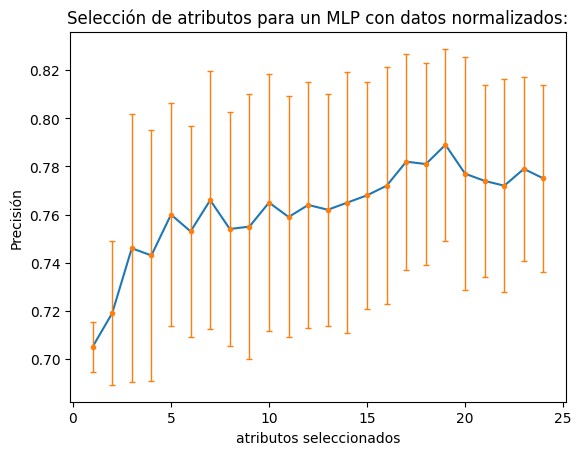

Atributos para precisión máxima con chi²(0.789): 19
Desviación para precisión máxima con chi²: 0.04
Desviación máxima registrada con chi²: 0.056
Precisión máxima sin selección de atributos 0.775


In [29]:
plt.title('Selección de atributos para un MLP con datos normalizados:')
plt.xlabel('atributos seleccionados')
plt.ylabel('Precisión')
plt.plot(n_features, scores_chi)
plt.errorbar(n_features, scores_chi, errors_chi, fmt='.', linewidth=1, capsize=2)
plt.show()
print(f'Atributos para precisión máxima con chi²({round(max_prec_chi[1], 4)}): {max_prec_chi[0]}')
print(f'Desviación para precisión máxima con chi²: {round(std_max_chi,3)}')
print(f'Desviación máxima registrada con chi²: {round(max(errors_chi),3)}')
print(f'Precisión máxima sin selección de atributos {round(scores_chi[-1], 4)}')

# 3. Análisis

## ¿Cómo se determina el valor de los hiperparámetros?

Para determinar el valor de los hiperparámetros de un modelo realizaremos una búsqueda en una rejilla. De entre los valores considerados seleccionaremos los que maximicen la estimación por validación cruzada (K = 10) de la tasa de acierto.

Adapta el código que encontrarás en 
[https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py)
a este problema. 

En los tutoriales
[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](
    https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
[https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
hay información sobre cada uno de los hiper-parámetros. 
Puedes elegir el conjunto de hiperparametros en el que se realiza la optimización. 
Antes de elegir la rejilla de hiperparámetros, asegúrate de que entiendes su para asegurarte que tiene sentido la búsqueda.

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import pandas as pd

df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)
X = df[feature_names].values
y = df[class_label].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Define the scores to select the best candidate
scores = ["precision", "recall"]

def print_dataframe(filtered_cv_results):
    """Pretty print for filtered dataframe"""
    for mean_precision, std_precision, mean_recall, std_recall, params in zip(
        filtered_cv_results["mean_test_precision"],
        filtered_cv_results["std_test_precision"],
        filtered_cv_results["mean_test_recall"],
        filtered_cv_results["std_test_recall"],
        filtered_cv_results["params"],
    ):
        print(
            f"precision: {mean_precision:0.3f} (±{std_precision:0.03f}),"
            f" recall: {mean_recall:0.3f} (±{std_recall:0.03f}),"
            f" for {params}"
        )
    print()

def refit_strategy(cv_results):
    """Define the strategy to select the best estimator.

    The strategy defined here is to filter-out all results below a precision threshold
    of 0.98, rank the remaining by recall and keep all models with one standard
    deviation of the best by recall. Once these models are selected, we can select the
    fastest model to predict.

    Parameters
    ----------
    cv_results : dict of numpy (masked) ndarrays
        CV results as returned by the `GridSearchCV`.

    Returns
    -------
    best_index : int
        The index of the best estimator as it appears in `cv_results`.
    """
    # print the info about the grid-search for the different scores
    precision_threshold = 0.98

    cv_results_ = pd.DataFrame(cv_results)
    print("All grid-search results:")
    print_dataframe(cv_results_)

    # Filter-out all results below the threshold
    high_precision_cv_results = cv_results_[
        cv_results_["mean_test_precision"] > precision_threshold
    ]

    print(f"Models with a precision higher than {precision_threshold}:")
    print_dataframe(high_precision_cv_results)

    high_precision_cv_results = high_precision_cv_results[
        [
            "mean_score_time",
            "mean_test_recall",
            "std_test_recall",
            "mean_test_precision",
            "std_test_precision",
            "rank_test_recall",
            "rank_test_precision",
            "params",
        ]
    ]

    # Select the most performant models in terms of recall
    # (within 1 sigma from the best)
    best_recall_std = high_precision_cv_results["mean_test_recall"].std()
    best_recall = high_precision_cv_results["mean_test_recall"].max()
    best_recall_threshold = best_recall - best_recall_std

    high_recall_cv_results = high_precision_cv_results[
        high_precision_cv_results["mean_test_recall"] > best_recall_threshold
    ]
    print(
        "Out of the previously selected high precision models, we keep all the\n"
        "the models within one standard deviation of the highest recall model:"
    )
    print_dataframe(high_recall_cv_results)

    # From the best candidates, select the fastest model to predict
    fastest_top_recall_high_precision_index = high_recall_cv_results[
        "mean_score_time"
    ].idxmin()

    print(
        "\nThe selected final model is the fastest to predict out of the previously\n"
        "selected subset of best models based on precision and recall.\n"
        "Its scoring time is:\n\n"
        f"{high_recall_cv_results.loc[fastest_top_recall_high_precision_index]}"
    )

    return fastest_top_recall_high_precision_index

# Define the hyper-parameters and create the grid-search instance
tuned_parameters = {
    'max_iter': [2000, 2500, 3000],
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search = GridSearchCV(
    MLPClassifier(), tuned_parameters, scoring=scores, refit=refit_strategy
)
grid_search.fit(X_train, y_train)

# Evaluate the fine-tuned model on the left-out evaluation set
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

## ¿Cómo se estima el error de generalización?

Estimaremos el error de generalización de cada clasificador usando *Nested Cross Validation*. 


Adapta el código que encontrarás en https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html para resolver este problema con una red neuronal. 


In [18]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import numpy as np
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

# Number of random trials
NUM_TRIALS = 30

mlpclf = MLPClassifier(hidden_layer_sizes=(50,50,), max_iter=1000, alpha=0.0, random_state = 42)

# Load the dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Set up possible values of parameters to optimize over
p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1]}

# Arrays to store scores
non_nested_scores = np.zeros(NUM_TRIALS)
nested_scores = np.zeros(NUM_TRIALS)

# Loop for each trial
for i in range(NUM_TRIALS):
    # Choose cross-validation techniques for the inner and outer loops,
    # independently of the dataset.
    # E.g "GroupKFold", "LeaveOneOut", "LeaveOneGroupOut", etc.
    inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

    # Non_nested parameter search and scoring
    clf = GridSearchCV(estimator=mlpclf, param_grid=p_grid, cv=outer_cv)
    clf.fit(X, y)
    non_nested_scores[i] = clf.best_score_

    # Nested CV with parameter optimization
    clf = GridSearchCV(estimator=mlpclf, param_grid=p_grid, cv=inner_cv)
    nested_score = cross_val_score(clf, X=X_iris, y=y_iris, cv=outer_cv)
    nested_scores[i] = nested_score.mean()

score_difference = non_nested_scores - nested_scores

print(
    "Average difference of {:6f} with std. dev. of {:6f}.".format(
        score_difference.mean(), score_difference.std()
    )
)

# Plot scores on each trial for nested and non-nested CV
plt.figure()
plt.subplot(211)
(non_nested_scores_line,) = plt.plot(non_nested_scores, color="r")
(nested_line,) = plt.plot(nested_scores, color="b")
plt.ylabel("score", fontsize="14")
plt.legend(
    [non_nested_scores_line, nested_line],
    ["Non-Nested CV", "Nested CV"],
    bbox_to_anchor=(0, 0.4, 0.5, 0),
)
plt.title(
    "Non-Nested and Nested Cross Validation on Iris Dataset",
    x=0.5,
    y=1.1,
    fontsize="15",
)

# Plot bar chart of the difference.
plt.subplot(212)
difference_plot = plt.bar(range(NUM_TRIALS), score_difference)
plt.xlabel("Individual Trial #")
plt.legend(
    [difference_plot],
    ["Non-Nested CV - Nested CV Score"],
    bbox_to_anchor=(0, 1, 0.8, 0),
)
plt.ylabel("score difference", fontsize="14")

plt.show()

## ¿Cuál es el mejor clasificador?

* De acuerdo con los resultados de los anteriores apartados, indica cuál es el mejor clasificador encontrado.

  El arbol de clasificaión es el más estable en sus resultados a la hora de realizar predicciones (tiene la desviación estándar más baja), pero un perceptrón la configuración adecuada de neuronas y capas puede superar su rendimiento, por cual, un clasificador mlp podría ser el mejor clasificador.
* ¿Cuáles son los valores de los **hiperparámetros** utilizados para configurar y entrenar tal  clasificador?
* ¿Cuáles son los valores de los **parámetros** del clasificador entrenado?
* Proporciona una estimación del error de generalización por validación cruzada, así como de la incertidumbre de dicha estimación.


## 4. Conclusiones.

Resume los resultados y conclusiones del estudio que has realizado.

En general podemos decir la elección de un clasificador a la hora de realizar predicciones sobre un conjunto de datos depende de como sea dicha conjunto y las transformaciones que se puedan hacer sobre este. Los clasificadores que mejor suelen rendir son las redes neuronales y los árboles de decisión.